# 02 - Preparacion de datos y entrenamiento del modelo

Corresponde a las etapas de **Preparacion de los datos**, **Modelado** y **Evaluacion** del proceso CRISP-DM.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay
)
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
RANDOM_STATE = 42

## 1. Carga y limpieza

In [2]:
df = pd.read_csv('data/diabetes_prediction_dataset.csv')
df = df[(df['age'] >= 30) & (df['age'] <= 64)].reset_index(drop=True)
print('Antes de quitar duplicados:', df.shape[0])

df = df.drop_duplicates().reset_index(drop=True)
print('Despues de quitar duplicados:', df.shape[0])

Antes de quitar duplicados: 48997
Despues de quitar duplicados: 47316


## 2. Codificacion de variables categoricas

In [3]:
print('Valores de gender:', df['gender'].unique())
print('Valores de smoking_history:', df['smoking_history'].unique())

# gender: variable binaria/categorica -> one-hot (se descarta 'Other' como categoria base si aplica)
df = pd.get_dummies(df, columns=['gender'], drop_first=True)

# smoking_history: variable ordinal aproximada -> mapeo manual
smoking_map = {
    'never': 0,
    'No Info': 0,
    'former': 1,
    'not current': 1,
    'ever': 1,
    'current': 2
}
df['smoking_history'] = df['smoking_history'].map(smoking_map)

df.head()

Valores de gender: <StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str
Valores de smoking_history: <StringArray>
['No Info', 'current', 'never', 'former', 'ever', 'not current']
Length: 6, dtype: str


,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other
0,54.0,0,0,0,27.32,6.6,80,0,False,False
1,36.0,0,0,2,23.45,5.0,155,0,False,False
2,44.0,0,0,0,19.31,6.5,200,1,False,False
3,42.0,0,0,0,33.64,4.8,145,0,True,False
4,32.0,0,0,0,27.32,5.0,100,0,False,False


## 3. Separacion de variables y particion train/test

In [4]:
X = df.drop(columns=['diabetes'])
y = df['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Proporcion de positivos en train:', y_train.mean().round(4))
print('Proporcion de positivos en test:', y_test.mean().round(4))

Train: (37852, 9)  Test: (9464, 9)
Proporcion de positivos en train: 0.0935
Proporcion de positivos en test: 0.0935


## 4. Escalado de variables numericas

In [5]:
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

## 5. Balanceo de clases (SMOTE)

El sobremuestreo se aplica **solo sobre el conjunto de entrenamiento**, nunca sobre el de prueba, para evitar que el modelo sea evaluado con datos sinteticos.

In [6]:
print('Antes de SMOTE:', y_train.value_counts().to_dict())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Despues de SMOTE:', y_train_bal.value_counts().to_dict())

Antes de SMOTE: {0: 34314, 1: 3538}
Despues de SMOTE: {0: 34314, 1: 34314}


## 6. Entrenamiento y comparacion de modelos

Se entrenan y comparan dos algoritmos: Regresion Logistica (modelo base/interpretable) y Random Forest (modelo de ensamble), evaluados con los indicadores definidos en la investigacion: Accuracy, Precision, Recall, F1-Score y AUC-ROC.

In [7]:
models = {
    'Regresion Logistica': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    fitted_models[name] = model

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).set_index('Modelo').round(4)
results_df

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Modelo,,,,,
Regresion Logistica,0.8693,0.4048,0.8452,0.5474,0.9473
Random Forest,0.9601,0.8279,0.7232,0.7720,0.9556


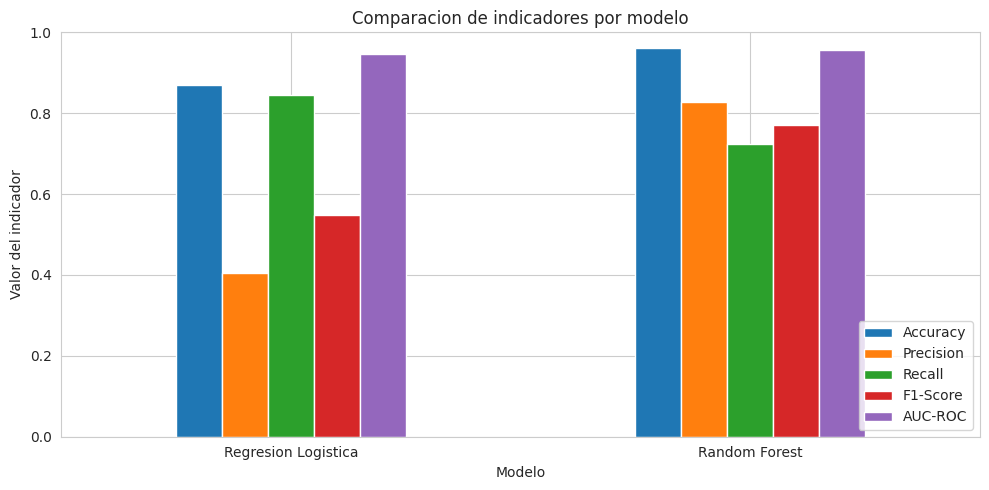

In [8]:
results_df.plot(kind='bar', figsize=(10, 5), ylim=(0, 1))
plt.title('Comparacion de indicadores por modelo')
plt.ylabel('Valor del indicador')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Curva ROC comparativa

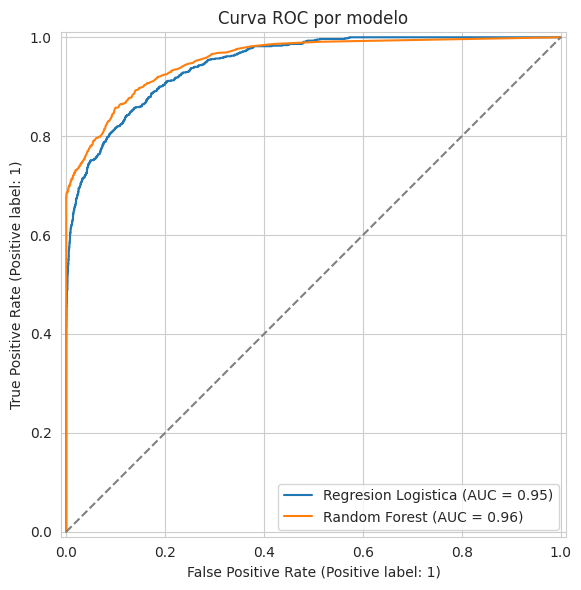

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
ax.set_title('Curva ROC por modelo')
plt.tight_layout()
plt.show()

## 8. Matriz de confusion del mejor modelo

Mejor modelo segun F1-Score: Random Forest


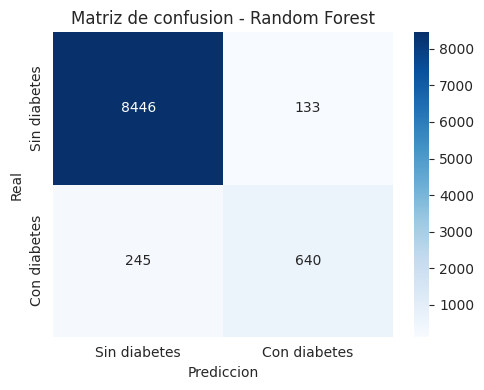

In [10]:
best_model_name = results_df['F1-Score'].idxmax()
best_model = fitted_models[best_model_name]
print('Mejor modelo segun F1-Score:', best_model_name)

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin diabetes', 'Con diabetes'],
            yticklabels=['Sin diabetes', 'Con diabetes'], ax=ax)
ax.set_xlabel('Prediccion')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de confusion - {best_model_name}')
plt.tight_layout()
plt.show()

## 9. Exportacion del modelo final

In [11]:
import os
os.makedirs('../models', exist_ok=True)

artifact = {
    'model': best_model,
    'scaler': scaler,
    'num_cols': num_cols,
    'feature_names': list(X_train.columns),
    'smoking_map': smoking_map
}

joblib.dump(artifact, '../models/diabetes_model_v1.joblib', compress=3)
print('Modelo exportado a models/diabetes_model_v1.joblib')
print('Variables esperadas por el modelo:', list(X_train.columns))

Modelo exportado a models/diabetes_model_v1.joblib
Variables esperadas por el modelo: ['age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Male', 'gender_Other']


## 10. Resumen de resultados

La tabla y graficos anteriores muestran el desempeno de cada modelo sobre el conjunto de prueba (no visto durante el entrenamiento ni el balanceo). El modelo seleccionado corresponde al de mejor F1-Score, indicador adecuado dado el desbalance original de clases, ya que pondera tanto la precision como el recall de la clase minoritaria (personas con diabetes).

El artefacto exportado (`diabetes_model_v1.joblib`) incluye el modelo entrenado, el escalador (`StandardScaler`) y los metadatos necesarios (nombres de columnas, mapeo de `smoking_history`) para que el backend (FastAPI) pueda aplicar exactamente el mismo preprocesamiento a los datos ingresados por el usuario antes de generar la prediccion.